In [1]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
from tqdm.notebook import tqdm
import gym_snakegame
from rewards import SnakeRewardWrapper

In [2]:
def get_allocentric_state(env):
    snake = env.unwrapped.snake
    if len(snake) == 0: 
        return (0,) * 6
    
    board = env.unwrapped.board
    head = snake[-1] # Snake Head X/Y
    target_val = env.unwrapped.ITEM
    
    target_pos = np.argwhere(board == target_val)[0]
    
    momentum_map = {
        0: (-1, 0), 
        1: (0, 1), 
        2: (1, 0),  
        3: (0, -1) 
    }
    
    prev_action = env.unwrapped.prev_action
    momentum = momentum_map.get(prev_action, (0, 0))

    return (
        float(head[0]),      # Snake Head Y
        float(head[1]),      # Snake Head X
        float(target_pos[0]),# Food Y
        float(target_pos[1]),# Food X
        float(momentum[0]),  # Y Momentum
        float(momentum[1])   # X Momentum
    )

def get_egocentric_state(env):
    snake = env.unwrapped.snake
    if len(snake) == 0: return (0,)*6
    board = env.unwrapped.board
    head = snake[-1]
    target_val = env.unwrapped.ITEM
    bs = env.unwrapped.board_size
    target_pos = np.argwhere(board == target_val)[0]
    prev_action = env.unwrapped.prev_action 

    dirs = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}
    curr_dir = dirs.get(prev_action, (0, 1)) 

    forward = curr_dir
    left = (-curr_dir[1], curr_dir[0])
    right = (curr_dir[1], -curr_dir[0])

    def is_unsafe(offset):
        r, c = head[0] + offset[0], head[1] + offset[1]
        if not (0 <= r < bs and 0 <= c < bs): return True
        return 0 < board[r, c] < target_val

    food_vec = (target_pos[0] - head[0], target_pos[1] - head[1])
    food_forward = np.sign(food_vec[0]*forward[0] + food_vec[1]*forward[1])
    food_lateral = np.sign(food_vec[0]*right[0] + food_vec[1]*right[1])

    return (is_unsafe(forward), is_unsafe(left), is_unsafe(right), 
            food_forward, food_lateral, prev_action)

In [3]:
def deterministic_policy(state, q_table):
    q_values = [q_table.get((state, i), 0.0) for i in range(4)]
    return np.argmax(q_values)

all_results = []
for r_type in ["sparse", "dense", "survivalist"]:
    for name in ["Allocentric", "Egocentric"]:
        path = f"final_results/models/{name}_{r_type}_Curriculum_q_table.pkl"
        with open(path, "rb") as f: q_table = pickle.load(f)
        state_func = get_allocentric_state if name == "Allocentric" else get_egocentric_state
        
        for grid_name, size in {"10x10": 10, "20x20": 20}.items():
            env = SnakeRewardWrapper(gym.make("gym_snakegame/SnakeGame-v0", board_size=size), r_type)
            metrics = []
            for _ in range(100):
                env.reset(); s = str(state_func(env)); done = False; ret, stp, fd = 0, 0, 0
                while not done and stp < 1000:
                    a = deterministic_policy(s, q_table) # GREEDY ACTION
                    _, r, term, trunc, info = env.step(a); s = str(state_func(env))
                    ret += r; stp += 1
                    if (r_type != "survivalist" and r == 10.0) or (r_type == "survivalist" and r == 5.0): fd += 1
                    done = term or trunc
                metrics.append({"r": ret, "l": info.get('snake_length', 3), "s": stp, "f": fd})
            
            df = pd.DataFrame(metrics)
            all_results.append({"System": r_type.capitalize(), "State": name, "Grid": grid_name, 
                                "Avg Return": df["r"].mean(), "Peak Length": df["l"].max(), 
                                "Steps/Food": df["s"].sum()/max(1, df["f"].sum()), "Success (%)": (df["l"] > 10).mean()*100})

/home/yarina/venvs/torch/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [4]:
df_final = pd.DataFrame(all_results)

# Table 2: 10x10 Baseline performance
print("TABLE 2: 10x10 Evaluation Metrics")
display(df_final[df_final["Grid"] == "10x10"])

# Table 3: Generalization Gap (Calculating cross-grid variance)
table3 = df_final.pivot_table(index=["System", "State"], columns="Grid", values="Avg Return").reset_index()
table3["Gap (%)"] = ((table3["10x10"] - table3["20x20"]) / table3["10x10"]) * 100
print("\nTABLE 3: Generalization Gap Analysis")
display(table3.sort_values("Gap (%)"))

TABLE 2: 10x10 Evaluation Metrics


,System,State,Grid,Avg Return,Peak Length,Steps/Food,Success (%)
0,Sparse,Allocentric,10x10,105.8000,32,8.253022,78.0
2,Sparse,Egocentric,10x10,30.1000,22,8.339152,14.0
4,Dense,Allocentric,10x10,135.8310,32,8.345133,92.0
6,Dense,Egocentric,10x10,100.2453,30,8.783078,68.0
8,Survivalist,Allocentric,10x10,93.9610,36,35.164877,84.0
10,Survivalist,Egocentric,10x10,58.0660,33,9.645341,84.0



TABLE 3: Generalization Gap Analysis


Grid,System,State,10x10,20x20,Gap (%)
5,Survivalist,Egocentric,58.0660,115.9135,-99.623704
2,Sparse,Allocentric,105.8000,198.1000,-87.240076
0,Dense,Allocentric,135.8310,226.4423,-66.708851
4,Survivalist,Allocentric,93.9610,151.2565,-60.977959
1,Dense,Egocentric,100.2453,155.0068,-54.627499
3,Sparse,Egocentric,30.1000,46.2000,-53.488372


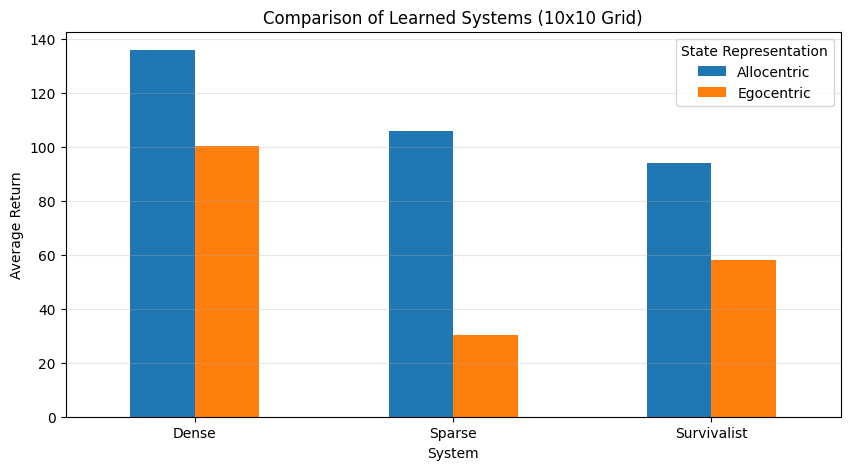

In [5]:
df_plot = df_final[df_final["Grid"] == "10x10"].pivot(index="System", columns="State", values="Avg Return")
df_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Comparison of Learned Systems (10x10 Grid)")
plt.ylabel("Average Return")
plt.xticks(rotation=0)
plt.legend(title="State Representation")
plt.grid(axis='y', alpha=0.3)
plt.show()